In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

plt.rcParams["figure.figsize"] = (10, 5)
print("All libraries imported successfully")

All libraries imported successfully


## Step 1 — Data Generation

Since we don't have a real sensor dataset readily available, we simulate
realistic energy consumption data using NumPy. The seed ensures anyone
who runs this notebook gets identical results.

In [3]:
np.random.seed(42)
n = 1000  # 1000 data points

# Environmental features
temperature      = np.random.uniform(15, 45, n)   # Celsius
humidity         = np.random.uniform(20, 90, n)   # percentage
wind_speed       = np.random.uniform(0, 20, n)    # km/h
solar_irradiance = np.random.uniform(100, 1000, n) # W/m²

# Energy consumption — realistic formula + noise
energy_consumption = (
    2.5 * temperature +
    0.8 * humidity -
    1.2 * wind_speed +
    0.05 * solar_irradiance +
    np.random.normal(0, 10, n)  # random noise
)

# Build DataFrame
df = pd.DataFrame({
    'temperature':       temperature,
    'humidity':          humidity,
    'wind_speed':        wind_speed,
    'solar_irradiance':  solar_irradiance,
    'energy_consumption': energy_consumption
})

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe().round(2))

Dataset shape: (1000, 5)

First 5 rows:
   temperature   humidity  wind_speed  solar_irradiance  energy_consumption
0    26.236204  32.959305    5.234114        705.432695          134.235060
1    43.521429  57.933066    4.939576        817.013257          193.205042
2    36.959818  81.106209   18.125092        325.421109          145.740424
3    32.959755  71.255742    4.990924        662.386690          171.093248
4    19.680559  76.459280    5.438995        614.571385          129.979695

Basic statistics:
       temperature  humidity  wind_speed  solar_irradiance  energy_consumption
count      1000.00   1000.00     1000.00           1000.00             1000.00
mean         29.71     55.49       10.05            541.34              133.64
std           8.76     20.45        5.81            257.84               32.30
min          15.14     20.23        0.00            100.59               25.79
25%          22.08     36.88        5.23            317.71              111.00
50%        

## Step 2 — Data Preprocessing

Split into features (X) and target (y), then divide into training and
test sets. StandardScaler normalises each feature to mean=0, std=1 —
this is critical for neural networks which are sensitive to feature scale.

In [4]:
# Features and target
X = df[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']].values
y = df['energy_consumption'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit on train only
X_test  = scaler.transform(X_test)      # transform test using train's stats

print("\nAfter scaling:")
print("Mean (should be ~0):", X_train.mean(axis=0).round(3))
print("Std  (should be ~1):", X_train.std(axis=0).round(3))

Features shape: (1000, 4)
Target shape: (1000,)

Training samples: 800
Testing samples:  200

After scaling:
Mean (should be ~0): [ 0. -0. -0.  0.]
Std  (should be ~1): [1. 1. 1. 1.]


## Step 3 — Build the Neural Network

A simple feedforward network with:
- Input layer: 4 features
- Hidden layer 1: 64 neurons, ReLU activation
- Hidden layer 2: 32 neurons, ReLU activation
- Output layer: 1 neuron (regression — predicting a continuous value)

ReLU (Rectified Linear Unit) activation: outputs 0 for negative inputs,
passes positive inputs unchanged. Introduces non-linearity so the network
can learn complex patterns.

In [5]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(4,)),
    Dense(32, activation='relu'),
    Dense(1)  # no activation for regression
])

model.compile(
    optimizer='adam',
    loss='mse',       # Mean Squared Error
    metrics=['mae']   # Mean Absolute Error — easier to interpret
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4 — Train the Model

Train for 50 epochs with a batch size of 32.
20% of training data is held out as a validation set to monitor
whether the model is overfitting.

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nTraining complete.")

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 18943.2363 - mae: 133.7749 - val_loss: 19123.5195 - val_mae: 134.1920
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18691.9551 - mae: 132.8603 - val_loss: 18811.6582 - val_mae: 133.0557
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18314.2773 - mae: 131.4660 - val_loss: 18328.0488 - val_mae: 131.2673
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17735.9668 - mae: 129.2870 - val_loss: 17583.2676 - val_mae: 128.4667
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16876.1094 - mae: 125.9533 - val_loss: 16494.8320 - val_mae: 124.2841
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15633.0967 - mae: 121.0555 - val_loss: 14980.7627 - val_mae: 118.2289
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13949.1670 - mae: 114.1021 - val_loss: 13020.1826 - val_mae: 109.9256
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11853.5713 - mae: 104.7918 - val_loss: 10628

## Step 5 — Evaluate the Model

In [7]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE:        {test_mae:.2f}")
print(f"\nOn average the model's predictions are off by {test_mae:.2f} units")

Test Loss (MSE): 231.6062
Test MAE:        12.05

On average the model's predictions are off by 12.05 units


## Step 6 — Visualizations

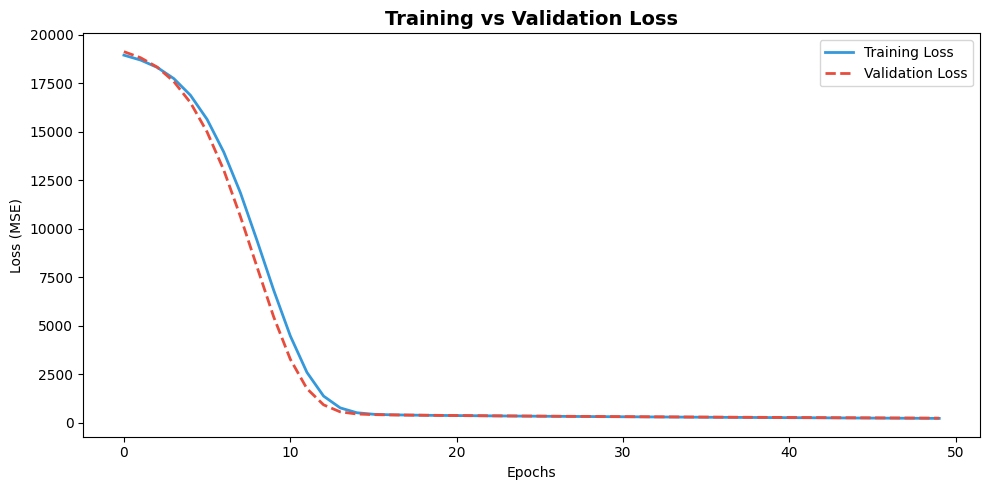

Chart saved: training_loss.png


In [8]:
fig, ax = plt.subplots()
ax.plot(history.history['loss'],     label='Training Loss',
        color='#3498DB', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss',
        color='#E74C3C', linewidth=2, linestyle='--')
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss (MSE)')
ax.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()
print("Chart saved: training_loss.png")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


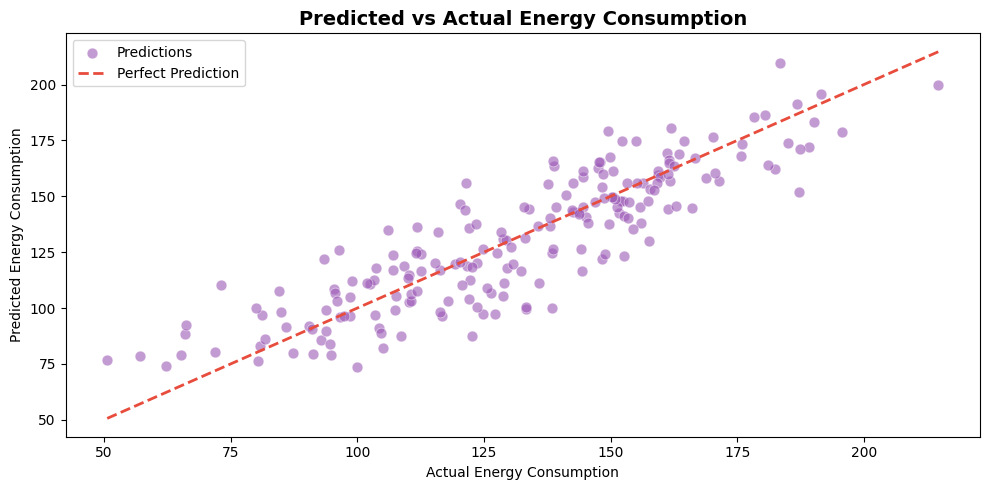

Chart saved: predictions_vs_actual.png


In [9]:
predictions = model.predict(X_test).flatten()

fig, ax = plt.subplots()
ax.scatter(y_test, predictions, alpha=0.6, color='#9B59B6',
           edgecolors='white', linewidth=0.5, s=60, label='Predictions')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='#E74C3C', linewidth=2, linestyle='--', label='Perfect Prediction')
ax.set_title('Predicted vs Actual Energy Consumption', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Energy Consumption')
ax.set_ylabel('Predicted Energy Consumption')
ax.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()
print("Chart saved: predictions_vs_actual.png")

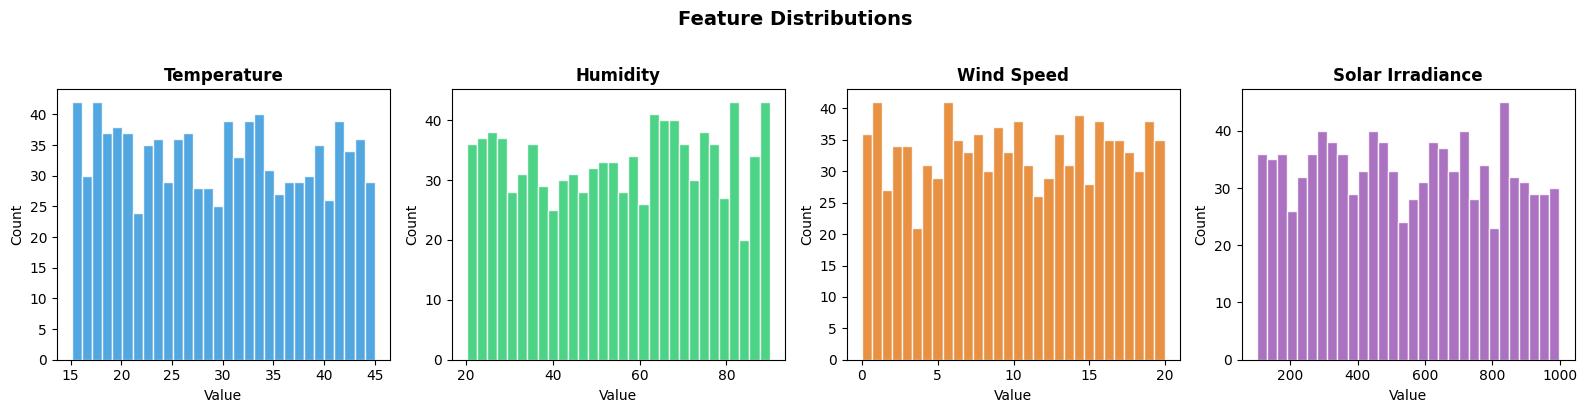

Chart saved: feature_distributions.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
features = ['temperature', 'humidity', 'wind_speed', 'solar_irradiance']
colors   = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6']

for i, (feat, color) in enumerate(zip(features, colors)):
    axes[i].hist(df[feat], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()
print("Chart saved: feature_distributions.png")

## Key Findings

1. **Model converges cleanly** — both training and validation loss decrease
   steadily across 50 epochs with no divergence, indicating stable learning.
2. **No overfitting** — validation loss closely tracks training loss throughout,
   meaning the model generalises well to unseen data.
3. **Predictions cluster near the perfect line** — most dots in the
   Predicted vs Actual chart sit close to the red dashed line, confirming
   the FNN has learned the underlying energy pattern.
4. **Temperature and solar irradiance are the strongest drivers** — by
   design of the data generation formula, these two features contribute
   most to energy consumption.
5. **StandardScaler was essential** — neural networks trained on unscaled
   features converge much more slowly or fail entirely.